# Dataset Preparation

**Dataset.**
This project uses the [AG News dataset](https://huggingface.co/datasets/sh0416/ag_news), which consists of short news articles covering diverse contemporary topics, including **World**, **Sports**, **Business**, and **Sci/Tech**.
The dataset was chosen because it contains modern vocabulary from multiple domains, making it suitable for training general-purpose Word2Vec embeddings.

In [1]:
from datasets import load_dataset

dst = load_dataset("sh0416/ag_news")

C:\Users\79635\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
len(dst["train"])

120000

In [3]:
dst["train"]["description"][99999]

' LONDON (Reuters) - Parliamentarians will table a motion on  Wednesday demanding a debate on Prime Minister Tony Blair\'s  "gross misconduct" in leading Britain to war against Iraq.'

In [4]:
dst["train"]["title"][99999]

"Politicians Seek Debate on Blair's Iraq 'Misconduct'"

In [5]:
from tqdm import tqdm

In [6]:
number_texts = 25000

**Tokenization and vocabulary construction.**

Each example in the dataset consists of a news title and its corresponding description, which are concatenated into a single text.
The text is then tokenized, and token frequencies are accumulated to build a vocabulary that reflects how often each word appears in the corpus.

In [7]:
from preprocessing import *

word_counts = Counter()
len_tokens = 0

for i in tqdm(range(number_texts)):
    example = dst["train"]["title"][i] + "." + dst["train"]["description"][i]
    len_tokens += len(tokenization(text=example, word_counts=word_counts))

100%|██████████| 25000/25000 [00:28<00:00, 892.14it/s] 


In [8]:
len_tokens

972678

In [9]:
len(word_counts.keys())

34782

In [10]:
word_counts.most_common(15)

[('the', 43619),
 ('to', 24708),
 ('a', 23022),
 ('in', 21196),
 ('of', 21185),
 ('and', 14888),
 ('on', 11977),
 ('for', 10417),
 ('that', 5672),
 ('with', 5526),
 ('at', 5413),
 ('as', 5338),
 ('new', 4678),
 ('its', 4532),
 ('by', 4504)]

**Rare word filtering.**

Words that appear only a few times in the corpus are removed, as such tokens are often noisy (e.g., typos or dataset-specific artifacts) and provide limited value for learning reliable word embeddings.
This filtering step helps reduce vocabulary size and improves the stability of the training process.

In [11]:
unique_words = [
    w for w, c in word_counts.items()
    if c > 5
]

In [12]:
len(unique_words)

11816

In [13]:
word_counts = Counter({
    w: c for w, c in word_counts.items()
    if w in unique_words
})

In [14]:
word2id = {}
id2word = {}

for idx, word in enumerate(unique_words):
    word2id[word] = idx
    id2word[idx] = word

In [15]:
encode_text(text=dst["train"]["title"][100] + "." + dst["train"]["description"][100],
            word2id=word2id,)

[1385,
 36,
 1391,
 863,
 30,
 1392,
 1393,
 1316,
 165,
 1316,
 165,
 30,
 1392,
 1393,
 634,
 63,
 1394,
 1385,
 36,
 852,
 1395,
 63,
 311,
 988,
 63,
 1391,
 990,
 6,
 1396,
 16,
 1397,
 345,
 1398,
 36,
 90,
 311,
 129,
 985,
 129,
 102,
 1399,
 1400]

In [16]:
len(word_counts) == len(unique_words)

True

In [17]:
id_counts = Counter({word2id[w]: c for w, c in word_counts.items()})
total_tokens = sum(word_counts.values())

Subsampling is a technique reduce the dominance of very frequent words (such as the, of, and) during training. Each word is randomly discarded with probability P, meaning that the more frequent a word is in the corpus, the more likely it is to be removed. This helps the model focus on more informative words and speeds up training.

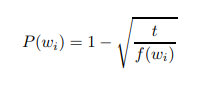

In [18]:
from dataset import *

article = dst["train"]["title"][4] + "." + dst["train"]["description"][4]
print("Text:")
print(article)
print()

toks = encode_text(article, word2id=word2id)
print("Tokens:")
print(toks)
print(len(toks))
print()

subsampled_tokens = subsample(toks, id_counts, total_tokens, t=1e-3)
print("Subsampled tokens:")
print(subsampled_tokens)
print(len(subsampled_tokens))

Text:
Oil prices soar to all-time record, posing new menace to US economy (AFP).AFP - Tearaway world oil prices, toppling records and straining wallets, present a new economic menace barely three months before the US presidential elections.

Tokens:
[50, 57, 97, 63, 98, 99, 100, 101, 102, 103, 63, 104, 51, 105, 105, 106, 50, 57, 107, 36, 108, 109, 110, 30, 102, 111, 103, 112, 113, 114, 115, 6, 104, 116, 117]
35

Subsampled tokens:
[50, 57, 97, 63, 98, 99, 100, 101, 103, 104, 51, 105, 105, 57, 107, 36, 108, 109, 110, 111, 103, 112, 114, 115, 116, 117]
26


In [19]:
from dataset import *

skipgram_pairs = []
context_window = 2

for i in tqdm(range(number_texts)):
    text = dst["train"]["title"][i] + "." + dst["train"]["description"][i]
    tokens = encode_text(text, word2id=word2id)
    pairs = build_skipgram_pairs(tokens, context_window, id_counts, total_tokens)
    skipgram_pairs.extend(pairs)

100%|██████████| 25000/25000 [00:23<00:00, 1072.05it/s]


In [20]:
len(skipgram_pairs)

2749540

In [21]:
#update word_counts
#because some words were deleted

word_counts = Counter({
    w: c for w, c in word_counts.items()
    if w in unique_words
})

In [22]:
len(word_counts) == len(unique_words)

True

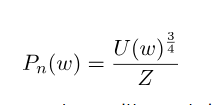

**Negative sampling distribution.**

The negative sampling distribution is defined as the unigram word frequency raised to the power of 0.75 and normalized by a constant
Z.
The function build_unigram_probs implements this formulation by computing the normalized probability distribution used to sample negative words during training.

In [23]:
import numpy as np

def build_unigram_probs(counts: np.ndarray, power: float = 0.75) -> np.ndarray:
    probs = counts ** power
    Z = probs.sum()
    probs /= Z
    return probs

In [24]:
word_counts_array = np.zeros(len(unique_words))

In [25]:
for i in range(len(word_counts_array)):
    current_word = id2word[i]
    freq = word_counts[current_word]
    word_counts_array[i] = freq

In [26]:
probs = build_unigram_probs(word_counts_array)

In [27]:
rng = np.random.default_rng(42)

In [28]:
print(len(id2word))

11816


# Gradient Checker


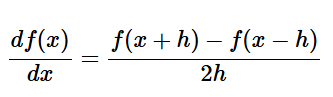
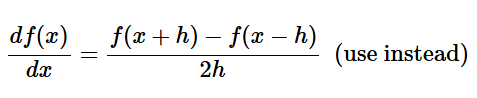

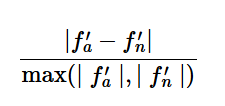

In [12]:
from gradient_checker import *
from SkipGram_NegativeSampling import *

In [16]:
vocab = 4
dim = 5
K = 3
B = 4

sample_model = Word2VecSGNS(vocab, dim, word2id=word2id, id2word=id2word)

center = np.random.randint(0, vocab, size=B)
pos = np.random.randint(0, vocab, size=B)
neg = np.random.randint(0, vocab, size=(B, K))

grad_check_used_only(sample_model, center, pos, neg)

Checking V...
V[0,0] rel=3.230e-09
V[0,1] rel=4.902e-09
V[0,2] rel=1.311e-08
V[0,3] rel=2.452e-08
V[0,4] rel=1.150e-09
V[1,0] rel=7.906e-09
V[1,1] rel=1.702e-08
V[1,2] rel=1.331e-09
V[1,3] rel=4.709e-10
V[1,4] rel=1.090e-08
V[3,0] rel=2.152e-09
V[3,1] rel=9.748e-09
V[3,2] rel=8.050e-09
V[3,3] rel=1.544e-09
V[3,4] rel=5.840e-10
Checking U...
U[0,0] rel=4.626e-10
U[0,1] rel=1.128e-08
U[0,2] rel=5.474e-09
U[0,3] rel=4.533e-10
U[0,4] rel=3.194e-08
U[1,0] rel=5.436e-09
U[1,1] rel=4.758e-09
U[1,2] rel=5.138e-09
U[1,3] rel=7.683e-09
U[1,4] rel=7.114e-09
U[2,0] rel=2.771e-09
U[2,1] rel=1.469e-07
U[2,2] rel=1.653e-08
U[2,3] rel=1.161e-09
U[2,4] rel=6.844e-09
U[3,0] rel=9.748e-11
U[3,1] rel=3.039e-08
U[3,2] rel=6.202e-09
U[3,3] rel=3.724e-07
U[3,4] rel=6.324e-09
Gradient check passed


# Training

To train the Skip-Gram with Negative Sampling model, the loss function shown above is optimized.
The text is processed using a sliding context window to form positive (center, context) pairs, while negative samples are selected dynamically during training via negative sampling.


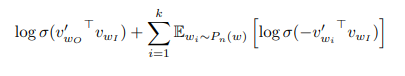

In [32]:

from training import *

model = Word2VecSGNS(vocab_size = len(unique_words), dim=100, word2id=word2id,
                     id2word=id2word)
train(model=model, data=skipgram_pairs, num_epochs=4, k=5, batch_size=128,
      probs=probs, rng=rng)

 25%|██▌       | 1/4 [09:01<27:04, 541.45s/it]

epoch 1: loss=4.1588


 50%|█████     | 2/4 [19:51<20:11, 605.54s/it]

epoch 2: loss=4.1579


 75%|███████▌  | 3/4 [29:54<10:04, 604.27s/it]

epoch 3: loss=4.1537


100%|██████████| 4/4 [41:39<00:00, 624.76s/it]

epoch 4: loss=4.1475


# Evaluation

For evaluation, a similarity function is used to retrieve the most similar word vectors by computing cosine similarity between embeddings.
Given a query word, the function returns the top-𝑁 closest words in the embedding space.

In [14]:
model = Word2VecSGNS(vocab_size = len(unique_words), dim=100,word2id={}, id2word={})
model.load("news_w2v_n2112596_v8777_d100_e5.npz")

In [15]:
len(model.word2id)

8777

In [16]:
from evaluation import *

get_top_n_similar_words(model, "olympic", model.word2id, model.id2word, n=10, use_central=True)

[('first', 0.99697826950206),
 ('gold', 0.9951372616882148),
 ('us', 0.9932829316256214),
 ('last', 0.9893457936909799),
 ('athens', 0.9889516843250038),
 ('medal', 0.9872723956826461),
 ('second', 0.9867220378519963),
 ('one', 0.9863675774149498),
 ('two', 0.9859518235912872),
 ('united', 0.9848083079869732)]

In [20]:
get_top_n_similar_words(model, "one", model.word2id, model.id2word, n=10, use_central=True)

[('two', 0.9942150718360443),
 ('out', 0.9915989182312115),
 ('first', 0.9908214285089013),
 ('us', 0.9903844063416398),
 ('last', 0.9900369492670396),
 ('second', 0.988178190239341),
 ('olympic', 0.9863675774149498),
 ('gold', 0.9850797134974025),
 ('three', 0.9838337713994053),
 ('this', 0.9827307321124124)]

In [21]:
get_top_n_similar_words(model, "monday", model.word2id, model.id2word, n=10, use_central=False)

[('thursday', 0.9978659939014025),
 ('tuesday', 0.9977364262874028),
 ('friday', 0.997632529971677),
 ('wednesday', 0.9973961261148838),
 ('sunday', 0.9762351743705828),
 ('saturday', 0.9678379501206874),
 ('officials', 0.9515005881934567),
 ('night', 0.9485368841014123),
 ('he', 0.943620511782305),
 ('they', 0.9424472009113012)]

In [17]:
plot_top_words_map(model, 190, word_counts)

The figure shows a visualization of the 190 most frequent words. Several semantic clusters can be observed: for instance, weekdays are grouped closely together, while weekend days appear slightly separated. Additionally, there is a noticeable cluster related to the Olympics and sports.

In [18]:
plot_example_cluster(model)

Shape: (34, 100)


In this experiment, I manually selected several semantic groups of words (days of the week, months, directions, colors, and animals). Their Word2Vec embeddings were extracted and clustered using the KMeans algorithm, and then visualized in two dimensions.

As shown in the figure, the days of the week form a clear cluster. Similarly, most of the months are located close to each other, indicating that the embeddings capture their semantic similarity.

An interesting observation is that the word “May” appears relatively far from the other months. This may be explained by its ambiguity, since may is also a modal verb in English.

The words representing directions (north, south, east, west) are assigned to the same cluster as several other words rather than forming a separate cluster. However, they are positioned close to each other in the embedding space and appear near the months cluster in the visualization.

In [19]:
plot_capital_relationships(model)

PCA projection of country and capital word embeddings showing consistent vector relationships between countries and their capitals.

In [20]:
plot_comparative_relations(model)

In this experiment, we examine how Word2Vec captures relationships between adjectives and their comparative and superlative forms. The embeddings of several adjective triplets (base, comparative, and superlative) were projected into two dimensions using PCA.

As shown in the figure, many adjective triplets appear relatively close to each other in the embedding space, suggesting that Word2Vec captures the relationship between different degrees of comparison. In several cases, the points representing the base, comparative, and superlative forms follow a similar directional pattern.

However, there are also some outliers. For example, the adjective “high” appears noticeably farther from its related forms compared to the other triplets, indicating that this relationship is not captured as consistently for all words.

In [21]:
plot_plural_relations(model)

In this experiment, we examine the relationship between singular and plural nouns in the Word2Vec embedding space. The vectors for several singular–plural word pairs were projected into two dimensions using PCA.

As shown in the figure, the vectors connecting singular and plural forms are not identical in length, and therefore they do not form perfectly consistent algebraic transformations across all words. This means that simple vector operations (for example, applying the same offset between unrelated words) would not always produce accurate results.

Nevertheless, most of the vectors point in a similar direction, indicating that the model captures a consistent transformation from singular to plural forms. Interestingly, this pattern also appears for irregular forms such as mouse → mice, where the plural is not formed by simply adding -s.

However, there are also some outliers. For example, the pair city → cities deviates noticeably from the general pattern and appears much farther away in the projection.